# VIKRAM KRISHNAREDDY
# STUDENT iD : 3220965
# LINK TO MY REPO :https://github.com/OPIM5512-pyb24001/myscrapers-pyb24001/tree/dw-dev


# # Model Trending Notebook

## 1. Objective

The goal of this notebook is to monitor how the car price prediction model performs over time as new data is collected and new prediction files are synced into the GitHub repository.

This notebook is designed to:
- clone the project repository
- read prediction outputs from the `results/` folder
- calculate model performance metrics over multiple runs
- build simple dashboard-style plots to track how model error changes over time
- review model interpretability outputs such as feature importance and PDP artifacts

This is important because in a real production pipeline, building a model once is not enough. We also need to monitor whether the model improves, stays stable, or changes as more data becomes available.

In [1]:

#. Clone the GitHub repository
# We clone the repository so that anyone with the notebook link
# can run this notebook without manually downloading files.
# This makes the notebook reproducible and easy to evaluate.

!git clone https://github.com/OPIM5512-pyb24001/myscrapers-pyb24001.git

# Move into the cloned repository
%cd myscrapers-pyb24001

Cloning into 'myscrapers-pyb24001'...
remote: Enumerating objects: 788, done.
remote: Counting objects: 100% (239/239), done.
remote: Compressing objects: 100% (203/203), done.
remote: Total 788 (delta 141), reused 77 (delta 30), pack-reused 549 (from 2)
Receiving objects: 100% (788/788), 1.02 MiB | 3.52 MiB/s, done.
Resolving deltas: 100% (313/313), done.
/content/myscrapers-pyb24001


## 2. Import Libraries and Inspect Available Results

In this step, I import the Python libraries needed for:
- reading files
- processing tabular data
- calculating metrics
- creating dashboard-style plots

I also inspect the `results/` folder to confirm which prediction, importance, and PDP files are currently available in the repository.

In [2]:

# 3. Import libraries
import pandas as pd
import numpy as np

# glob: helps us read multiple files matching a pattern
import glob
import os
import matplotlib.pyplot as plt



# 4. Inspect files in results folder
# These files are the saved outputs from the live pipeline.
# We check them first so we know what artifacts are available.

pred_files = sorted(glob.glob("results/*-preds.csv"))
importance_files = sorted(glob.glob("results/*-importance.csv"))
pdp_files = sorted(glob.glob("results/*-pdp.png"))

print("Number of prediction files:", len(pred_files))
print("Number of importance files:", len(importance_files))
print("Number of PDP files:", len(pdp_files))

print("\nPrediction files:")
print(pred_files)

print("\nImportance files:")
print(importance_files)

print("\nPDP files:")
print(pdp_files)

Number of prediction files: 23
Number of importance files: 19
Number of PDP files: 19

Prediction files:
['results/2026040223-preds.csv', 'results/20260403T012430Z-preds.csv', 'results/20260403T032010Z-preds.csv', 'results/20260403T052309Z-preds.csv', 'results/20260403T060049Z-preds.csv', 'results/20260403T062002Z-preds.csv', 'results/20260403T082012Z-preds.csv', 'results/20260403T092011Z-preds.csv', 'results/20260403T102011Z-preds.csv', 'results/20260403T112011Z-preds.csv', 'results/20260403T132014Z-preds.csv', 'results/20260403T152012Z-preds.csv', 'results/20260403T162012Z-preds.csv', 'results/20260403T172010Z-preds.csv', 'results/20260403T192011Z-preds.csv', 'results/20260403T202010Z-preds.csv', 'results/20260403T212013Z-preds.csv', 'results/20260403T222018Z-preds.csv', 'results/20260403T232015Z-preds.csv', 'results/20260404T032014Z-preds.csv', 'results/20260404T042011Z-preds.csv', 'results/20260404T062012Z-preds.csv', 'results/20260404T072040Z-preds.csv']

Importance files:
['resul

## 3. Combine Prediction Files Across Runs

Each prediction file represents one model run. In this step, I load all prediction files from the `results/` folder, extract the corresponding `run_id` from the file name, and combine them into one dataset.

This is important because model trending requires comparing performance across multiple runs rather than looking at only one file at a time.

In [3]:

# 5. Load and combine prediction files

# We read each prediction file, attach its run_id, and then
# combine everything into one table for analysis over time.

all_predictions = []

for file in pred_files:
    # Read one prediction file
    df_temp = pd.read_csv(file)

    # Extract run_id from file name
    run_id = os.path.basename(file).replace("-preds.csv", "")

    # Add run_id to the dataframe
    df_temp["run_id"] = run_id

    # Store it in a list
    all_predictions.append(df_temp)

# Combine all runs into one dataframe
preds_all = pd.concat(all_predictions, ignore_index=True)

# Show dataset shape and preview
print("Combined prediction table shape:", preds_all.shape)
preds_all.head()

Combined prediction table shape: (3411, 10)


,post_id,scraped_at,make,model,year,mileage,price,price_num,pred_price,run_id
0,7924386182,2026-04-02 18:00:17+00:00,TOYOTA,CAMRY SE,2012,93250.0,13800.0,13800.0,7085.681349,2026040223
1,7924375576,2026-04-02 21:00:06+00:00,Cadillac,CTS Premium,2012,170000.0,7995.0,7995.0,3828.211667,2026040223
2,7924262826,2026-04-02 22:00:37+00:00,Volvo,240,1990,252300.0,1200.0,1200.0,5342.215000,2026040223
3,7924062352,2026-04-02 21:00:06+00:00,subaru,impreza,2015,183000.0,4800.0,4800.0,5941.110000,2026040223
4,7924043271,2026-04-02 22:00:37+00:00,Chevrolet,Avalanche,2005,215000.0,5800.0,5800.0,3682.565333,2026040223


## 4. Compute Model Performance Metrics Per Run

In this step, I calculate model performance metrics for each run.

Metrics used:
- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- MAPE (Mean Absolute Percentage Error)
- Bias (average prediction error)

This is important because it allows us to track how the model performs over time as new data is collected.

In [4]:

# 4 Compute metrics per run

# We group predictions by run_id and calculate metrics for each run.

results = []

for run_id, group in preds_all.groupby("run_id"):

    # Actual values
    y_true = group["price_num"]

    # Predicted values
    y_pred = group["pred_price"]

    # MAE: average absolute error
    mae = np.mean(np.abs(y_true - y_pred))

    # RMSE: penalizes large errors more
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))

    # MAPE: percentage-based error
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    # Bias: whether model over/under predicts
    bias = np.mean(y_pred - y_true)

    results.append({
        "run_id": run_id,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "Bias": bias
    })

# Convert to DataFrame
metrics_df = pd.DataFrame(results)

# Sort by run order
metrics_df = metrics_df.sort_values("run_id")

metrics_df

,run_id,MAE,RMSE,MAPE,Bias
0,2026040223,5558.866755,15741.690381,67.859053,-1820.767846
1,20260403T012430Z,5524.547996,9392.866676,150.928485,3192.406357
2,20260403T032010Z,5848.561221,12048.362987,110.768701,1580.611506
3,20260403T052309Z,5019.796549,10180.777904,80.366979,-132.754505
4,20260403T060049Z,6557.523458,18817.938545,79.386118,-1777.794420
5,20260403T062002Z,6557.523458,18817.938545,79.386118,-1777.794420
6,20260403T082012Z,5916.568826,16853.109082,76.524168,-1150.731475
7,20260403T092011Z,6141.036825,17202.301309,74.921513,-1423.964808
8,20260403T102011Z,6074.605129,16280.908201,75.390399,-1388.666357
9,20260403T112011Z,5880.598972,16105.547639,69.886826,-1739.050616


## 5. Model Performance Dashboard

In this step, I visualize how model performance changes over time.

These plots help answer:
- Is the model improving as more data is collected?
- Is the error stable or fluctuating?
- Are there any unusual spikes in error?

This is similar to real-world ML monitoring dashboards used in production systems.

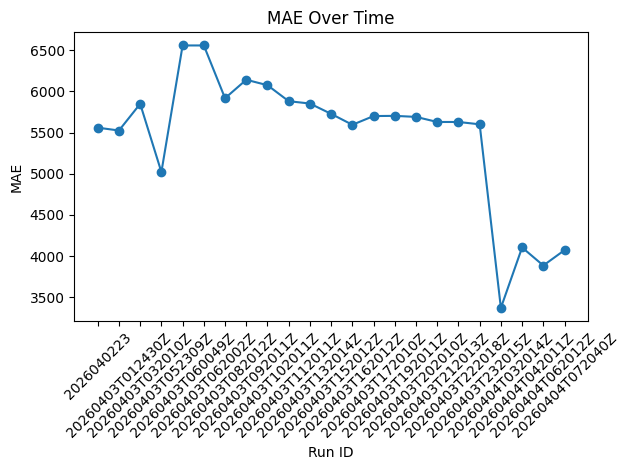

In [5]:

# 5A. Plot MAE over time

# MAE shows the average absolute prediction error for each run.

plt.figure()

plt.plot(metrics_df["run_id"], metrics_df["MAE"], marker='o')

# Rotate run labels so they are easier to read
plt.xticks(rotation=45)

plt.title("MAE Over Time")
plt.xlabel("Run ID")
plt.ylabel("MAE")

plt.tight_layout()
plt.show()

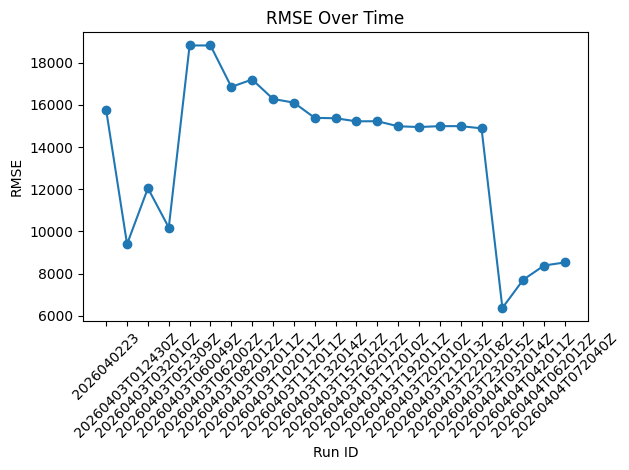

In [6]:

# 5B. Plot RMSE over time

# RMSE gives more weight to larger errors and helps identify
# whether some runs contain especially difficult predictions.

plt.figure()

plt.plot(metrics_df["run_id"], metrics_df["RMSE"], marker='o')

plt.xticks(rotation=45)

plt.title("RMSE Over Time")
plt.xlabel("Run ID")
plt.ylabel("RMSE")

plt.tight_layout()
plt.show()

### Dashboard Observations

- Model performance changes across runs rather than staying fixed.
- This is expected in a live pipeline because new listings are added continuously.
- RMSE is consistently higher than MAE, which suggests some runs contain larger prediction errors or outliers.
- The dashboard helps monitor whether the model remains stable as more data is collected.

## 6. Feature Importance Dashboard

In this step, I analyze the feature importance files generated by the live pipeline.

Each importance file shows which features had the strongest impact on model predictions for a given run. Tracking these files over time helps us understand whether the model is relying on the same patterns or whether feature influence changes as new data is collected.

This is important because model monitoring is not only about error metrics. It is also about understanding how the model is making decisions over time.

In [7]:
# -----------------------------
# 6A. Load and combine importance files
# -----------------------------
# Each importance file belongs to one run.
# We read them, attach the run_id, and combine them into one table.

importance_list = []

for file in importance_files:

    # Read one importance file
    df_temp = pd.read_csv(file)

    # Extract run_id from file name
    run_id = os.path.basename(file).replace("-importance.csv", "")

    # Add run_id column so we know which run each feature belongs to
    df_temp["run_id"] = run_id

    # Store in list
    importance_list.append(df_temp)

# Combine all importance files into one dataframe
importance_all = pd.concat(importance_list, ignore_index=True)

# Sort for readability
importance_all = importance_all.sort_values(["run_id", "importance"], ascending=[True, False])

# Show preview
importance_all.head()

,feature,importance,run_id
0,car_age,0.158287,20260403T060049Z
1,log_mileage,0.048212,20260403T060049Z
2,miles_per_year,0.038278,20260403T060049Z
3,city,0.017932,20260403T060049Z
4,condition,0.003992,20260403T060049Z


In [8]:
# -----------------------------
# 6B. Show top features for each run
# -----------------------------
# This helps us quickly see which features were most important
# in each model run.

top_features_by_run = importance_all.groupby("run_id").head(5)

top_features_by_run

,feature,importance,run_id
0,car_age,0.158287,20260403T060049Z
1,log_mileage,0.048212,20260403T060049Z
2,miles_per_year,0.038278,20260403T060049Z
3,city,0.017932,20260403T060049Z
4,condition,0.003992,20260403T060049Z
...,...,...,...
234,car_age,0.277787,20260404T072040Z
235,city,0.082726,20260404T072040Z
236,miles_per_year,0.074143,20260404T072040Z
237,model,0.043953,20260404T072040Z


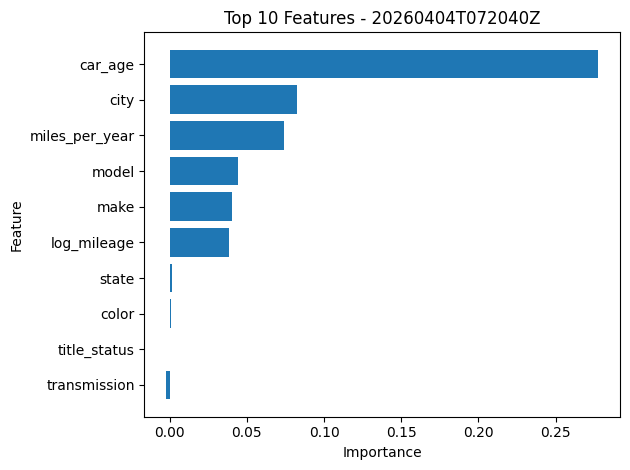

In [9]:
# -----------------------------
# 6C. Plot top features for latest run
# -----------------------------
# Here we visualize the 10 most important features for the most recent run.

latest_run = importance_all["run_id"].max()

latest_importance = (
    importance_all[importance_all["run_id"] == latest_run]
    .sort_values("importance", ascending=False)
    .head(10)
)

plt.figure()

plt.barh(latest_importance["feature"], latest_importance["importance"])

# Put most important feature at the top
plt.gca().invert_yaxis()

plt.title(f"Top 10 Features - {latest_run}")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### Feature Importance Observations

- The latest run shows which variables are currently driving the model's predictions most strongly.
- If the same features remain important across runs, that suggests the model is learning stable pricing patterns.
- If feature rankings change over time, that may indicate that the data distribution is evolving as new listings are collected.
- This provides a model interpretability view that complements the error dashboard.

## 7. Partial Dependence Plots (PDP) and Final Observations

In this step, I review the Partial Dependence Plot (PDP) outputs generated by the live pipeline.

PDP plots show how individual features affect the predicted price while keeping other variables constant. These plots help interpret how the model responds to key features such as car age, mileage, and usage patterns.

This completes the model monitoring workflow by combining:
- performance tracking (metrics)
- feature importance
- feature behavior (PDP)

Showing PDP for: results/20260404T072040Z-pdp.png


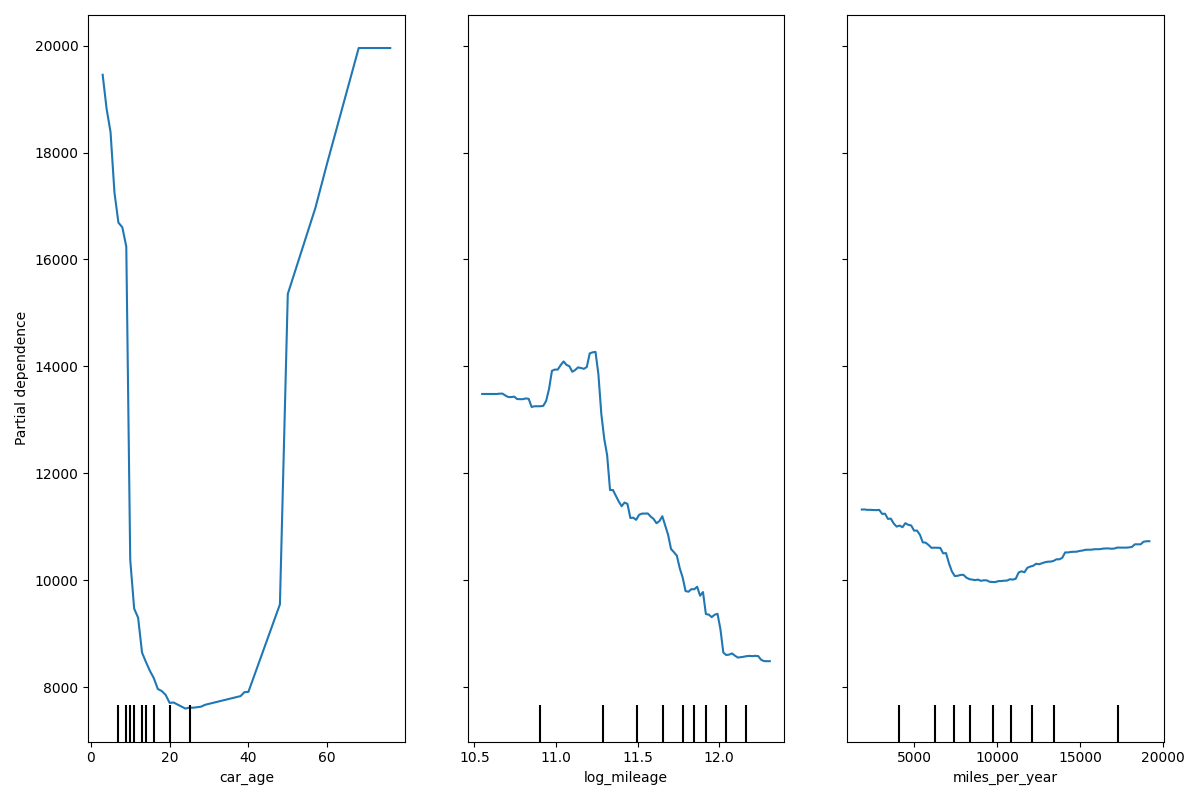

In [10]:
# -----------------------------
# 7A. Display PDP image for latest run
# -----------------------------
# We display the PDP image saved by the pipeline for the most recent run.

from IPython.display import Image, display

if len(pdp_files) > 0:
    latest_pdp = sorted(pdp_files)[-1]

    print("Showing PDP for:", latest_pdp)
    display(Image(filename=latest_pdp))
else:
    print("No PDP files found.")

### PDP Observations

- The PDP plots illustrate how the model responds to key numerical features such as car_age, log_mileage, and miles_per_year.
- As car_age increases, predicted prices generally decrease, reflecting depreciation.
- Higher mileage (log_mileage) is associated with lower predicted prices.
- miles_per_year helps capture how intensively a vehicle has been used, which also impacts pricing.

These plots provide a clear interpretation of model behavior and help validate that the model is learning realistic patterns.

## Final Summary

This notebook demonstrates a complete production-style machine learning pipeline:

- Data is continuously scraped and processed using LLM-based ETL.
- A tuned Random Forest model is trained on historical data.
- Predictions are generated for new listings and stored with timestamps.
- Model performance is tracked over time using MAE, RMSE, MAPE, and Bias.
- Feature importance and PDP plots provide interpretability.
- All outputs are automatically synced to GitHub for monitoring.

This approach reflects real-world machine learning systems, where models are not only trained but continuously evaluated and monitored as new data arrives.